# Prioridade Criminal — Municípios do Estado de São Paulo

Classificação de municípios em níveis **Baixa / Média / Alta** prioridade criminal
a partir de indicadores criminais defasados (ano anterior).

**Escopo dos dados.** A base da SSP-SP cobre apenas os municípios com maior porte
populacional — **79 municípios**, não os 645 do estado. Qualquer conclusão vale para
esse recorte, não para o estado inteiro.

**Aviso.** Projeto acadêmico. O modelo aprende padrões estatísticos em *crime
registrado*, não em crime ocorrido, e não estabelece causalidade. Não deve ser usado
isoladamente para decisões de segurança pública. Ver a seção de Limitações ao final.


## 1. Imports e carregamento


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import shap
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedGroupKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    recall_score,
    cohen_kappa_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

RANDOM_STATE = 123

path = kagglehub.dataset_download(
    "dbwaller/official-crime-data-sao-paulo-statebrazil-ssp"
)

file_path = os.path.join(
    path,
    "ds_SSP_CrimeRate_SP-BR_utf8_2001-2020_.csv"
)

df = pd.read_csv(file_path, sep=';', encoding='utf-8')
print(df.shape)


100%|██████████| 4.76M/4.76M [00:00<00:00, 82.6MB/s]

Extracting files...


(2304, 10)


## 2. Limpeza e conversão numérica


In [2]:
df.head()


,Ano,Homicídio Doloso por 100 mil habitantes,Furto por 100 mil habitantes,Roubo por 100 mil habitantes,Furto e Roubo de Veículo por 100 mil habitantes,Furto por 100 mil veículos,Roubo por 100 mil veículos,Furto e Roubo de Veículo por 100 mil veículos,Cidade,Regiao
0,1999.0,"52,58","1.085,19","1.068,39","1.108,17",-,-,-,São Paulo,Capital
1,2000.0,"51,23","1.034,32","1.046,44","1.175,01",-,-,-,São Paulo,Capital
2,2001.0,"49,16","1.099,04","1.066,06","1.032,52","1.423,03","1.275,53","2.698,56",São Paulo,Capital
3,2002.0,"43,63","1.190,92","1.137,27","907,16","1.249,70","1.035,15","2.284,84",São Paulo,Capital
4,2003.0,"39,97","1.333,79","1.237,66","868,17","1.158,55","946,79","2.105,34",São Paulo,Capital


In [3]:
df.dtypes


,0
Ano,float64
Homicídio Doloso por 100 mil habitantes,object
Furto por 100 mil habitantes,object
Roubo por 100 mil habitantes,object
Furto e Roubo de Veículo por 100 mil habitantes,object
Furto por 100 mil veículos,object
Roubo por 100 mil veículos,object
Furto e Roubo de Veículo por 100 mil veículos,object
Cidade,object
Regiao,object


In [4]:
# Homicídio usa vírgula decimal sem separador de milhar: 52,58 -> 52.58
df['Homicídio Doloso por 100 mil habitantes'] = (
    df['Homicídio Doloso por 100 mil habitantes']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace('-', np.nan)
    .astype(float)
)

# Demais colunas usam ponto de milhar: 1.085,19 -> 1085.19
colunas_br = [
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes',
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

for col in colunas_br:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('-', np.nan)
        .astype(float)
    )

df.dtypes


,0
Ano,float64
Homicídio Doloso por 100 mil habitantes,float64
Furto por 100 mil habitantes,float64
Roubo por 100 mil habitantes,float64
Furto e Roubo de Veículo por 100 mil habitantes,float64
Furto por 100 mil veículos,float64
Roubo por 100 mil veículos,float64
Furto e Roubo de Veículo por 100 mil veículos,float64
Cidade,object
Regiao,object


In [5]:
df.isna().sum()


,0
Ano,566
Homicídio Doloso por 100 mil habitantes,566
Furto por 100 mil habitantes,566
Roubo por 100 mil habitantes,566
Furto e Roubo de Veículo por 100 mil habitantes,566
Furto por 100 mil veículos,724
Roubo por 100 mil veículos,724
Furto e Roubo de Veículo por 100 mil veículos,724
Cidade,0
Regiao,0


In [6]:
colunas_crime = [
    'Homicídio Doloso por 100 mil habitantes',
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes',
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

# Linhas em que TODOS os indicadores são nulos: são linhas separadoras do CSV
# (o próprio campo 'Ano' também vem vazio nelas).
linhas_sem_crime = df[df[colunas_crime].isna().all(axis=1)]
print("Linhas totalmente vazias:", len(linhas_sem_crime))
print("Dessas, com 'Ano' também nulo:", linhas_sem_crime['Ano'].isna().sum())


Linhas totalmente vazias: 566
Dessas, com 'Ano' também nulo: 566


In [7]:
df_limpo = df.dropna(subset=colunas_crime, how='all').copy()
df_limpo['Ano'] = df_limpo['Ano'].astype(int)
df_limpo.isnull().sum()


,0
Ano,0
Homicídio Doloso por 100 mil habitantes,0
Furto por 100 mil habitantes,0
Roubo por 100 mil habitantes,0
Furto e Roubo de Veículo por 100 mil habitantes,0
Furto por 100 mil veículos,158
Roubo por 100 mil veículos,158
Furto e Roubo de Veículo por 100 mil veículos,158
Cidade,0
Regiao,0


In [8]:
# Os NaN restantes estão apenas nas taxas por 100 mil VEÍCULOS,
# e apenas em 1999-2000 (a frota municipal não era publicada nesses anos).
df_limpo[df_limpo['Furto por 100 mil veículos'].isna()].groupby('Ano').size()


,0
Ano,
1999,79
2000,79


### 2.1 Zeros impossíveis nas taxas por veículo

Os boxplots por região revelaram um problema na região de **Santos**: alguns
municípios-ano trazem `0,00` simultaneamente em *Furto por 100 mil veículos*,
*Roubo por 100 mil veículos* e *Furto e Roubo de Veículo por 100 mil veículos*.

Esses zeros **não podem ser reais**, e a prova está na própria linha: o mesmo
município-ano registra *Furto e Roubo de Veículo por 100 mil **habitantes*** em torno
de 140–200, ou seja, houve crime de veículo. Um valor positivo por habitante com valor
zero por veículo é logicamente contraditório — trata-se de falha no **denominador**
(frota municipal ausente ou zerada na fonte), e não de ausência de crime.

Efeito colateral no gráfico: em escala logarítmica, `log(0)` é indefinido, então o
Plotly descarta silenciosamente esses pontos. A caixa de Santos aparecia truncada e
calculada sobre menos observações do que as demais — foi exatamente essa a estranheza
visual.

**Tratamento:** os zeros dessas três colunas são convertidos em `NaN` (dado ausente).
Isso **não afeta nenhum resultado do modelo**, porque as taxas por veículo já estavam
excluídas do índice e das features por indisponibilidade em 1999–2000. A correção vale
para a integridade da análise exploratória.


In [ ]:
colunas_veiculo = [
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

# Linhas com zero nas taxas por veículo, mas com crime de veículo por habitante:
# contradição interna -> denominador (frota) inválido na fonte.
suspeitas = df_limpo[
    (df_limpo[colunas_veiculo] == 0).any(axis=1)
    & (df_limpo['Furto e Roubo de Veículo por 100 mil habitantes'] > 0)
]

print("Municípios-ano com zero impossível nas taxas por veículo:", len(suspeitas))
display(
    suspeitas[['Ano', 'Cidade', 'Regiao',
               'Furto e Roubo de Veículo por 100 mil habitantes'] + colunas_veiculo]
)

# Converte os zeros em ausente (NaN)
df_limpo[colunas_veiculo] = df_limpo[colunas_veiculo].replace(0, np.nan)
print("\nNaN nas taxas por veículo após o tratamento:")
print(df_limpo[colunas_veiculo].isna().sum())


In [9]:
# Escopo real da base
print("Observações:", len(df_limpo))
print("Municípios :", df_limpo['Cidade'].nunique())
print("Anos       :", df_limpo['Ano'].min(), "a", df_limpo['Ano'].max())
print("Regiões    :", df_limpo['Regiao'].nunique())
print()
print("Observações por município (deve ser constante se o painel for balanceado):")
print(df_limpo.groupby('Cidade').size().value_counts())


Observações: 1738
Municípios : 79
Anos       : 1999 a 2020
Regiões    : 12

Observações por município (deve ser constante se o painel for balanceado):
22    79
Name: count, dtype: int64


### 2.2 Outliers

Os valores extremos foram **mantidos**: são plausíveis historicamente (Diadema com
102 homicídios/100 mil em 1999 corresponde ao que a literatura registra para a Grande
São Paulo no período).

Há, porém, duas ressalvas sobre o **denominador**, e ambas apontam para o mesmo tipo
de distorção:

- **Polos regionais.** As taxas usam a população *residente*, mas o registro ocorre no
  município onde fica o Distrito Policial. Barretos, Araçatuba e Bauru concentram
  registros de uma microrregião inteira sobre a própria população, o que infla a taxa
  artificialmente. O pico de 4.053 furtos/100 mil em Barretos provavelmente reflete
  isso, e não criminalidade proporcionalmente maior.
- **Municípios litorâneos.** Praia Grande atinge 4.919 furtos por 100 mil veículos, o
  maior valor da base. Cidades de veraneio têm população flutuante muito acima da
  residente no verão, e frota visitante que não entra no denominador — o mesmo viés,
  por outra causa.

Em ambos os casos o outlier é **coerente como registro** e **enganoso como taxa**.


In [10]:
# Distribuição de cada indicador (escala log por causa da assimetria)
for col in colunas_crime:
    fig = px.box(
        df_limpo,
        y=col,
        x='Regiao',
        log_y=True,
        title=f'Distribuição por região: {col}',
        labels={'Regiao': 'Região', col: 'Valor (escala log)'}
    )
    fig.update_xaxes(tickangle=45)
    fig.show()


In [11]:
# Os 10 maiores valores de cada indicador, para checar se os extremos são coerentes
for col in colunas_crime:
    print(f"\n===== {col} =====")
    display(
        df_limpo[['Ano', 'Cidade', 'Regiao', col]]
        .sort_values(col, ascending=False)
        .head(10)
    )



===== Homicídio Doloso por 100 mil habitantes =====


,Ano,Cidade,Regiao,Homicídio Doloso por 100 mil habitantes
92,1999,Diadema,Grande São Paulo (exclui a Capital),102.82
116,2001,Embu das Artes,Grande São Paulo (exclui a Capital),93.56
248,1999,Itapevi,Grande São Paulo (exclui a Capital),91.45
226,1999,Itapecerica da Serra,Grande São Paulo (exclui a Capital),87.32
114,1999,Embu das Artes,Grande São Paulo (exclui a Capital),79.15
228,2001,Itapecerica da Serra,Grande São Paulo (exclui a Capital),78.65
431,2000,Santana de Parnaíba,Grande São Paulo (exclui a Capital),76.78
227,2000,Itapecerica da Serra,Grande São Paulo (exclui a Capital),76.17
93,2000,Diadema,Grande São Paulo (exclui a Capital),76.15
271,2000,Itaquaquecetuba,Grande São Paulo (exclui a Capital),75.98



===== Furto por 100 mil habitantes =====


,Ano,Cidade,Regiao,Furto por 100 mil habitantes
1030,2005,Barretos,Ribeirão Preto,4053.04
1032,2007,Barretos,Ribeirão Preto,3601.00
1029,2004,Barretos,Ribeirão Preto,3527.46
1031,2006,Barretos,Ribeirão Preto,3351.39
2225,2003,Araçatuba,Araçatuba,3335.47
2226,2004,Araçatuba,Araçatuba,3279.17
1028,2003,Barretos,Ribeirão Preto,3236.78
1033,2008,Barretos,Ribeirão Preto,3100.85
1034,2009,Barretos,Ribeirão Preto,3023.84
1229,2001,Bauru,Bauru,2929.71



===== Roubo por 100 mil habitantes =====


...

,Ano,Cidade,Regiao,Furto por 100 mil veículos
1620,2001,Praia Grande,Santos,4919.26
1622,2003,Praia Grande,Santos,3145.51
1624,2005,Praia Grande,Santos,3035.77
1623,2004,Praia Grande,Santos,2895.09
1625,2006,Praia Grande,Santos,2786.22
1621,2002,Praia Grande,Santos,2757.17
1626,2007,Praia Grande,Santos,2242.23
362,2001,Osasco,Grande São Paulo (exclui a Capital),2092.89
498,2001,São Caetano do Sul,Grande São Paulo (exclui a Capital),2044.01
140,2002,Ferraz de Vasconcelos,Grande São Paulo (exclui a Capital),2003.58



===== Roubo por 100 mil veículos =====


,Ano,Cidade,Regiao,Roubo por 100 mil veículos
272,2001,Itaquaquecetuba,Grande São Paulo (exclui a Capital),3626.24
94,2001,Diadema,Grande São Paulo (exclui a Capital),3257.76
454,2001,Santo André,Grande São Paulo (exclui a Capital),2971.38
455,2002,Santo André,Grande São Paulo (exclui a Capital),2756.60
116,2001,Embu das Artes,Grande São Paulo (exclui a Capital),2631.46
543,2001,Taboão da Serra,Grande São Paulo (exclui a Capital),2404.16
117,2002,Embu das Artes,Grande São Paulo (exclui a Capital),2366.31
72,2001,Cotia,Grande São Paulo (exclui a Capital),2311.21
456,2003,Santo André,Grande São Paulo (exclui a Capital),2220.17
106,2013,Diadema,Grande São Paulo (exclui a Capital),2219.10



===== Furto e Roubo de Veículo por 100 mil veículos =====


,Ano,Cidade,Regiao,Furto e Roubo de Veículo por 100 mil veículos
1620,2001,Praia Grande,Santos,5887.41
272,2001,Itaquaquecetuba,Grande São Paulo (exclui a Capital),5510.46
94,2001,Diadema,Grande São Paulo (exclui a Capital),4953.42
454,2001,Santo André,Grande São Paulo (exclui a Capital),4520.11
543,2001,Taboão da Serra,Grande São Paulo (exclui a Capital),4385.97
116,2001,Embu das Artes,Grande São Paulo (exclui a Capital),4280.75
455,2002,Santo André,Grande São Paulo (exclui a Capital),4132.89
1624,2005,Praia Grande,Santos,4116.59
1625,2006,Praia Grande,Santos,4073.13
1622,2003,Praia Grande,Santos,4001.77


## 3. Índice de Prioridade Criminal

O índice combina quatro indicadores padronizados por Z-score:

- Homicídio Doloso por 100 mil habitantes;
- Furto por 100 mil habitantes;
- Roubo por 100 mil habitantes;
- Furto e Roubo de Veículo por 100 mil habitantes.

As taxas por 100 mil **veículos** foram excluídas por não existirem em 1999–2000.

**Sobre os pesos.** Adotou-se peso igual como escolha de referência transparente —
mas peso igual *não* é ausência de juízo de valor. Somar z-scores com peso 1 afirma
que **um desvio-padrão de furto equivale a um desvio-padrão de homicídio**, o que é
uma equivalência forte entre crimes de gravidades muito distintas. Além disso, furto,
roubo e furto/roubo de veículo são fortemente correlacionados entre si, de modo que o
índice pondera crime patrimonial três vezes e crime letal uma vez.

Por isso a seção 3.3 testa a **sensibilidade** do índice a especificações alternativas
de peso.

**Padronização sem vazamento.** Média e desvio-padrão de cada indicador são estimados
**apenas com 1999–2015** e aplicados a 2016–2020. Consequência deliberada: o índice do
período de teste é medido na régua da era de treino, e não recentrado em si mesmo.


In [12]:
colunas_indice = [
    'Homicídio Doloso por 100 mil habitantes',
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes'
]

colunas_z = [f'z_{c}' for c in colunas_indice]


### 3.1 Correlação entre os indicadores


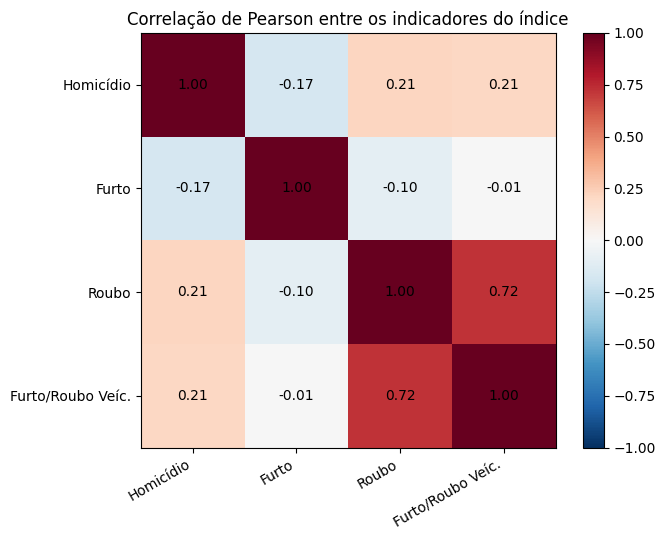

,Homicídio Doloso por 100 mil habitantes,Furto por 100 mil habitantes,Roubo por 100 mil habitantes,Furto e Roubo de Veículo por 100 mil habitantes
Homicídio Doloso por 100 mil habitantes,1.000,-0.170,0.215,0.207
Furto por 100 mil habitantes,-0.170,1.000,-0.096,-0.007
Roubo por 100 mil habitantes,0.215,-0.096,1.000,0.725
Furto e Roubo de Veículo por 100 mil habitantes,0.207,-0.007,0.725,1.000


In [13]:
corr = df_limpo[colunas_indice].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
rotulos = ['Homicídio', 'Furto', 'Roubo', 'Furto/Roubo Veíc.']
ax.set_xticks(range(4)); ax.set_xticklabels(rotulos, rotation=30, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(rotulos)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center')
plt.colorbar(im)
plt.title('Correlação de Pearson entre os indicadores do índice')
plt.tight_layout()
plt.show()

display(corr.round(3))


### 3.2 Padronização (Z-score ajustado só no treino)


In [14]:
treino_mask = df_limpo['Ano'] <= 2015
teste_mask  = df_limpo['Ano'] > 2015

# Um scaler por coluna, ajustado SOMENTE no período de treino.
scalers = {}

for col in colunas_indice:
    z_col = f'z_{col}'
    sc = StandardScaler().fit(df_limpo.loc[treino_mask, [col]])
    scalers[col] = sc

    df_limpo.loc[treino_mask, z_col] = sc.transform(
        df_limpo.loc[treino_mask, [col]]
    ).ravel()

    df_limpo.loc[teste_mask, z_col] = sc.transform(
        df_limpo.loc[teste_mask, [col]]
    ).ravel()

# Sanidade: no treino a média deve ser ~0 e o desvio ~1; no teste, não.
print("Treino (esperado ~0 / ~1):")
print(df_limpo.loc[treino_mask, colunas_z].agg(['mean', 'std']).round(3))
print("\nTeste (deslocamento indica queda/alta real da criminalidade):")
print(df_limpo.loc[teste_mask, colunas_z].agg(['mean', 'std']).round(3))


Treino (esperado ~0 / ~1):
      z_Homicídio Doloso por 100 mil habitantes  \
mean                                        0.0   
std                                         1.0   

      z_Furto por 100 mil habitantes  z_Roubo por 100 mil habitantes  \
mean                            -0.0                            -0.0   
std                              1.0                             1.0   

      z_Furto e Roubo de Veículo por 100 mil habitantes  
mean                                                0.0  
std                                                 1.0  

Teste (deslocamento indica queda/alta real da criminalidade):
      z_Homicídio Doloso por 100 mil habitantes  \
mean                                     -0.689   
std                                       0.278   

      z_Furto por 100 mil habitantes  z_Roubo por 100 mil habitantes  \
mean                          -0.567                          -0.080   
std                            0.670                           1.30

In [15]:
df_limpo['indice_prioridade'] = df_limpo[colunas_z].sum(axis=1)
df_limpo['indice_prioridade'].describe()


,indice_prioridade
count,1738.000000
mean,-0.368335
std,2.368733
min,-5.297380
25%,-2.077055
50%,-0.640560
75%,0.829942
max,10.799113


### 3.3 Sensibilidade a especificações alternativas de peso


In [16]:
# Três especificações alternativas, para medir o quanto a classificação final
# depende da escolha de pesos.
df_limpo['indice_homicidio2'] = (
    2 * df_limpo[f'z_{colunas_indice[0]}']
    + df_limpo[f'z_{colunas_indice[1]}']
    + df_limpo[f'z_{colunas_indice[2]}']
    + df_limpo[f'z_{colunas_indice[3]}']
)

# PCA ajustado só no treino: deixa os dados escolherem o peso.
pca = PCA(n_components=1).fit(df_limpo.loc[treino_mask, colunas_z])
df_limpo['indice_pca'] = pca.transform(df_limpo[colunas_z]).ravel()

# Garante que o PC1 aponte no sentido de "mais crime"
if np.corrcoef(df_limpo['indice_pca'], df_limpo['indice_prioridade'])[0, 1] < 0:
    df_limpo['indice_pca'] *= -1

print("Variância explicada pelo PC1:", pca.explained_variance_ratio_[0].round(3))
print("Cargas do PC1:", dict(zip(
    ['Homicídio', 'Furto', 'Roubo', 'Veículo'],
    (pca.components_[0] * np.sign(pca.components_[0].sum())).round(3)
)))


def classes_por_tercil(serie):
    lim_b = serie[treino_mask.values].quantile(0.33)
    lim_a = serie[treino_mask.values].quantile(0.66)
    return pd.cut(
        serie,
        bins=[-np.inf, lim_b, lim_a, np.inf],
        labels=[0, 1, 2]
    ).astype(int)


cls_base = classes_por_tercil(df_limpo['indice_prioridade'])
for nome, col in [('Homicídio peso 2', 'indice_homicidio2'), ('PCA (PC1)', 'indice_pca')]:
    cls_alt = classes_por_tercil(df_limpo[col])
    print(f"\n{nome}: concordância com o índice de pesos iguais = "
          f"{(cls_alt == cls_base).mean():.1%}")
    display(pd.crosstab(cls_base, cls_alt,
                        rownames=['pesos iguais'], colnames=[nome]))


Variância explicada pelo PC1: 0.481
Cargas do PC1: {'Homicídio': np.float64(0.38), 'Furto': np.float64(-0.273), 'Roubo': np.float64(0.638), 'Veículo': np.float64(0.612)}

Homicídio peso 2: concordância com o índice de pesos iguais = 87.8%


Homicídio peso 2,0,1,2
pesos iguais,,,
0,653,41,0
1,60,427,50
2,0,61,446



PCA (PC1): concordância com o índice de pesos iguais = 61.7%


PCA (PC1),0,1,2
pesos iguais,,,
0,433,247,14
1,140,250,147
2,45,73,389


## 4. Alvo e desenho temporal

O alvo é o tercil do índice no ano *t*; as features são os quatro indicadores brutos
no ano *t−1*. Os limiares dos tercis vêm **apenas** do período de treino.

**Consequência a ter em mente:** como a criminalidade em SP caiu de 2016 a 2020 e a
régua ficou fixa em 1999–2015, "Alta prioridade" no teste **não** significa "alto em
relação aos contemporâneos" — significa "tão alto quanto o tercil superior da era
1999–2015". Por isso a distribuição de classes no teste é fortemente desbalanceada,
enquanto a de treino é ~33/33/33 por construção. Isso é *prior shift*, e afeta a
leitura de todas as métricas.


In [17]:
treino_temp = df_limpo[df_limpo['Ano'] <= 2015]

limiar_baixa_media = treino_temp['indice_prioridade'].quantile(0.33)
limiar_media_alta  = treino_temp['indice_prioridade'].quantile(0.66)

df_limpo['target_prioridade'] = pd.cut(
    df_limpo['indice_prioridade'],
    bins=[-np.inf, limiar_baixa_media, limiar_media_alta, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(f"Limiares (só treino): {limiar_baixa_media:.3f} | {limiar_media_alta:.3f}")


Limiares (só treino): -1.148 | 0.523


In [18]:
df_limpo = df_limpo.sort_values(['Cidade', 'Ano']).reset_index(drop=True)

# Features defasadas (ano anterior) e classe defasada (para o baseline de persistência)
for col in colunas_indice:
    df_limpo[f'lag_{col}'] = df_limpo.groupby('Cidade')[col].shift(1)

df_limpo['lag_target'] = df_limpo.groupby('Cidade')['target_prioridade'].shift(1)
df_limpo['lag_ano'] = df_limpo.groupby('Cidade')['Ano'].shift(1)

features_lag = [f'lag_{col}' for col in colunas_indice]

df_modelo = df_limpo.dropna(subset=features_lag + ['lag_target']).copy()

# O shift(1) só é um "ano anterior" de verdade se os anos forem contíguos.
salto = (df_modelo['Ano'] - df_modelo['lag_ano']) != 1
print("Linhas com defasagem NÃO contígua:", salto.sum())
df_modelo = df_modelo[~salto].copy()

assert ((df_modelo['Ano'] - df_modelo['lag_ano']) == 1).all()
print("Observações utilizáveis:", len(df_modelo))


Linhas com defasagem NÃO contígua: 0
Observações utilizáveis: 1659


In [19]:
treino = df_modelo[df_modelo['Ano'] <= 2015].copy()
teste  = df_modelo[df_modelo['Ano'] > 2015].copy()

X_treino, y_treino = treino[features_lag], treino['target_prioridade']
X_teste,  y_teste  = teste[features_lag],  teste['target_prioridade']

grupos_treino = treino['Cidade']

print("Features:", features_lag)
print(f"\nTreino: {len(treino)} obs, {treino['Cidade'].nunique()} municípios, "
      f"{treino['Ano'].min()}-{treino['Ano'].max()}")
print(f"Teste : {len(teste)} obs, {teste['Cidade'].nunique()} municípios, "
      f"{teste['Ano'].min()}-{teste['Ano'].max()}")

comp = pd.DataFrame({
    'treino': y_treino.value_counts(normalize=True).sort_index(),
    'teste':  y_teste.value_counts(normalize=True).sort_index(),
})
comp.index = ['Baixa', 'Média', 'Alta']
print("\nDistribuição de classes (prior shift):")
display(comp.round(3))


Features: ['lag_Homicídio Doloso por 100 mil habitantes', 'lag_Furto por 100 mil habitantes', 'lag_Roubo por 100 mil habitantes', 'lag_Furto e Roubo de Veículo por 100 mil habitantes']

Treino: 1264 obs, 79 municípios, 2000-2015
Teste : 395 obs, 79 municípios, 2016-2020

Distribuição de classes (prior shift):


,treino,teste
Baixa,0.335,0.635
Média,0.330,0.238
Alta,0.335,0.127


## 5. Baselines

Antes de qualquer modelo, é preciso saber **contra o que** comparar. O alvo em *t* é
uma função determinística dos indicadores em *t*, e as features são os mesmos
indicadores em *t−1*. Como taxas criminais municipais são altamente persistentes, boa
parte do desempenho é explicada por inércia, não por aprendizado.

Dois baselines:

1. **Prior (`DummyClassifier`)** — chuta sempre a classe majoritária do treino.
2. **Persistência** — a classe de *t* é a classe de *t−1*. Usa exatamente a mesma
   informação disponível ao modelo, sem aprender nada.

Qualquer modelo só é interessante se superar o baseline de persistência.


In [ ]:
def avaliar(y_true, y_pred, nome):
    return {
        'modelo': nome,
        'acurácia': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'recall_alta': recall_score(y_true, y_pred, labels=[2], average='macro'),
        'kappa_quad': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
    }


linhas_baseline = []

# Atenção: no treino as três classes têm frequência praticamente igual (33/33/33),
# então o 'most_frequent' resolve o empate escolhendo UMA classe e a prevê sempre.
# Se cair na classe Alta, o recall da Alta vai a 1,00 com acurácia de 0,13 —
# demonstração útil de que recall isolado não mede desempenho.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_treino, y_treino)
linhas_baseline.append(avaliar(y_teste, dummy.predict(X_teste), 'Baseline: classe majoritária'))

y_pred_persist = teste['lag_target'].astype(int)
linhas_baseline.append(avaliar(y_teste, y_pred_persist, 'Baseline: persistência (classe de t-1)'))

df_baselines = pd.DataFrame(linhas_baseline).set_index('modelo')
display(df_baselines.round(3))

print("\nRelatório do baseline de persistência:")
print(classification_report(y_teste, y_pred_persist,
                            target_names=['Baixa', 'Média', 'Alta'], zero_division=0))


## 6. Comparação de modelos

Duas correções em relação a uma validação cruzada ingênua:

**Agrupamento por município.** `StratifiedKFold(shuffle=True)` colocaria Diadema 2003
no treino e Diadema 2004 na validação — praticamente a mesma observação. Cada fold
vazaria informação do município para si mesmo, inflando o AUC e distorcendo o
*ranking* dos algoritmos. Usa-se `StratifiedGroupKFold` agrupando por `Cidade`, de
modo que um município **nunca** aparece em treino e validação ao mesmo tempo.

**Ajuste de hiperparâmetros.** Comparar oito algoritmos nos valores padrão compara
*defaults*, não algoritmos. Cada modelo passa por uma busca em grade pequena dentro da
mesma CV agrupada.

O `best_score_` da busca é otimista (foi maximizado sobre a grade). A estimativa não
enviesada é o conjunto de teste temporal 2016–2020, usado na seção 7.

*Observação sobre balanceamento:* Logistic Regression, SVM, Decision Tree e Random
Forest usam `class_weight='balanced'`; Gradient Boosting, XGBoost, KNN e Naive Bayes
não têm esse parâmetro. É uma assimetria conhecida da comparação.


In [21]:
cv_agrupada = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_e_grades = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()),
                  ('model', LogisticRegression(class_weight='balanced', max_iter=5000))]),
        {'model__C': [0.01, 0.1, 1, 10]}
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()),
                  ('model', SVC(class_weight='balanced', probability=True,
                                random_state=RANDOM_STATE))]),
        {'model__C': [0.1, 1, 10], 'model__gamma': ['scale', 0.1]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()),
                  ('model', KNeighborsClassifier())]),
        {'model__n_neighbors': [5, 15, 31], 'model__weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 10, 30]}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'n_estimators': [300], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    ),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
        {'n_estimators': [100, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 4]}
    ),
    'Naive Bayes': (
        GaussianNB(),
        {'var_smoothing': [1e-9, 1e-6, 1e-3]}
    ),
}


In [22]:
resultados_cv = {}
melhores = {}

for nome, (estimador, grade) in modelos_e_grades.items():
    busca = GridSearchCV(
        estimador,
        grade,
        cv=cv_agrupada,
        scoring='roc_auc_ovr',
        n_jobs=-1,
        refit=True,
    )
    busca.fit(X_treino, y_treino, groups=grupos_treino)

    melhores[nome] = busca.best_estimator_
    resultados_cv[nome] = {
        'AUC_cv': busca.best_score_,
        'std_cv': busca.cv_results_['std_test_score'][busca.best_index_],
        'melhores_params': busca.best_params_,
    }
    print(f"{nome}: AUC = {busca.best_score_:.3f} "
          f"(+/- {resultados_cv[nome]['std_cv']:.3f}) | {busca.best_params_}")


Logistic Regression: AUC = 0.920 (+/- 0.021) | {'model__C': 10}
SVM: AUC = 0.916 (+/- 0.023) | {'model__C': 1, 'model__gamma': 0.1}
KNN: AUC = 0.903 (+/- 0.026) | {'model__n_neighbors': 31, 'model__weights': 'distance'}
Decision Tree: AUC = 0.830 (+/- 0.051) | {'max_depth': 8, 'min_samples_leaf': 10}
Random Forest: AUC = 0.888 (+/- 0.040) | {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Gradient Boosting: AUC = 0.893 (+/- 0.028) | {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
XGBoost: AUC = 0.897 (+/- 0.027) | {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
Naive Bayes: AUC = 0.864 (+/- 0.042) | {'var_smoothing': 1e-06}


In [23]:
df_cv = (
    pd.DataFrame(resultados_cv).T
    .sort_values('AUC_cv', ascending=False)
)
display(df_cv)


,AUC_cv,std_cv,melhores_params
Logistic Regression,0.919559,0.02131,{'model__C': 10}
SVM,0.915937,0.023031,"{'model__C': 1, 'model__gamma': 0.1}"
KNN,0.902913,0.026042,"{'model__n_neighbors': 31, 'model__weights': '..."
XGBoost,0.897357,0.027226,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
Gradient Boosting,0.8934,0.027641,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
Random Forest,0.88816,0.040113,"{'max_depth': None, 'min_samples_leaf': 5, 'n_..."
Naive Bayes,0.86354,0.042116,{'var_smoothing': 1e-06}
Decision Tree,0.829596,0.050949,"{'max_depth': 8, 'min_samples_leaf': 10}"


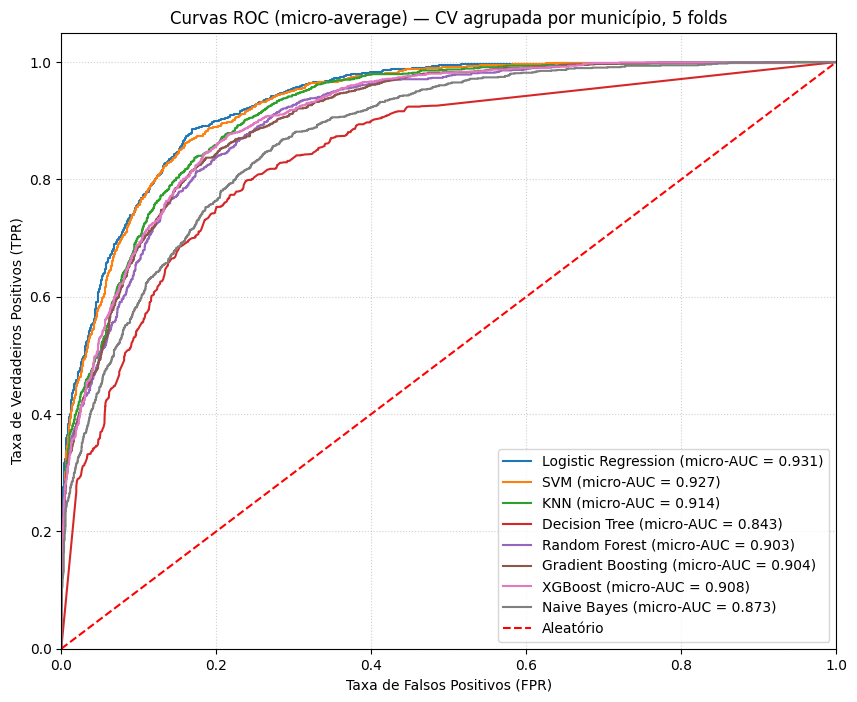

In [24]:
plt.figure(figsize=(10, 8))
classes = np.unique(y_treino)
y_bin = label_binarize(y_treino, classes=classes)

for nome, modelo in melhores.items():
    y_probas = cross_val_predict(
        modelo, X_treino, y_treino,
        cv=cv_agrupada, groups=grupos_treino,
        method='predict_proba', n_jobs=-1,
    )
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_probas.ravel())
    plt.plot(fpr, tpr, label=f"{nome} (micro-AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'r--', label='Aleatório')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC (micro-average) — CV agrupada por município, 5 folds')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 7. Avaliação no teste temporal (2016–2020)

**Todos** os oito modelos são avaliados no conjunto de teste, junto com os dois
baselines. Avaliar apenas dois modelos e depois afirmar que o escolhido supera "os
demais" seria uma conclusão sem suporte.

Métricas: acurácia, F1 macro, recall da classe Alta e **kappa quadrático ponderado**.
O kappa entra porque o alvo é **ordinal** (Baixa < Média < Alta) e as demais métricas
tratam o erro Baixa→Alta como equivalente ao erro Baixa→Média, quando o primeiro é
claramente pior.


In [25]:
linhas_teste = list(linhas_baseline)

for nome, modelo in melhores.items():
    linhas_teste.append(avaliar(y_teste, modelo.predict(X_teste), nome))

df_teste = (
    pd.DataFrame(linhas_teste)
    .set_index('modelo')
    .sort_values('f1_macro', ascending=False)
)
display(df_teste.round(3))


,acurácia,f1_macro,recall_alta,kappa_quad
modelo,,,,
Baseline: persistência (classe de t-1),0.818,0.776,0.90,0.833
Logistic Regression,0.805,0.760,0.90,0.824
SVM,0.792,0.745,0.90,0.814
XGBoost,0.790,0.739,0.88,0.809
KNN,0.782,0.732,0.90,0.807
Random Forest,0.772,0.713,0.90,0.791
Gradient Boosting,0.770,0.704,0.92,0.785
Naive Bayes,0.739,0.683,0.88,0.746
Decision Tree,0.732,0.670,0.86,0.733


===== Logistic Regression =====
              precision    recall  f1-score   support

       Baixa       0.98      0.83      0.90       251
       Média       0.58      0.69      0.63        94
        Alta       0.65      0.90      0.76        50

    accuracy                           0.81       395
   macro avg       0.73      0.81      0.76       395
weighted avg       0.84      0.81      0.81       395



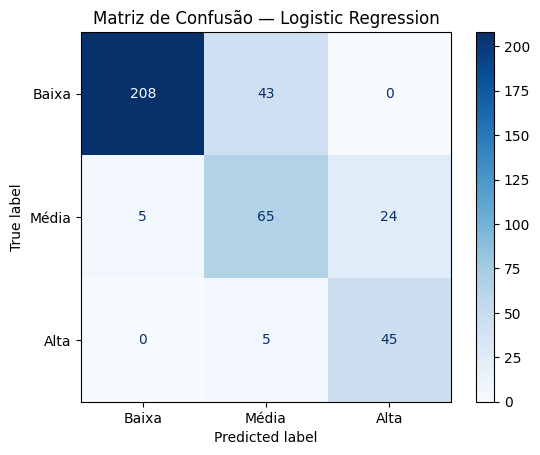

===== SVM =====
              precision    recall  f1-score   support

       Baixa       0.97      0.82      0.89       251
       Média       0.55      0.66      0.60        94
        Alta       0.63      0.90      0.74        50

    accuracy                           0.79       395
   macro avg       0.72      0.79      0.75       395
weighted avg       0.83      0.79      0.80       395



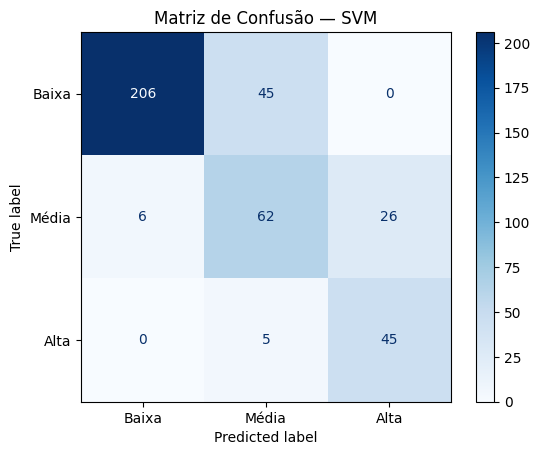

In [26]:
# Comparação detalhada entre os dois melhores e o baseline de persistência
top2 = df_teste.drop(index=[i for i in df_teste.index if i.startswith('Baseline')]).index[:2]

for nome in list(top2):
    y_pred = melhores[nome].predict(X_teste)
    print(f"===== {nome} =====")
    print(classification_report(y_teste, y_pred,
                                target_names=['Baixa', 'Média', 'Alta'], zero_division=0))
    ConfusionMatrixDisplay.from_predictions(
        y_teste, y_pred, display_labels=['Baixa', 'Média', 'Alta'], cmap='Blues'
    )
    plt.title(f"Matriz de Confusão — {nome}")
    plt.show()


### 7.1 Efeito do `class_weight` sob *prior shift*

O modelo foi treinado numa distribuição ~33/33/33 e aplicado numa ~64/24/13. Com
`class_weight='balanced'` ele tenderia a reforçar as classes minoritárias do teste,
superprevendo "Alta" e derrubando a precisão dessa classe.

A célula abaixo mede esse efeito. **Resultado observado:** `balanced` e `None`
produzem previsões idênticas (69 "Alta" previstas contra 50 reais em ambos os casos).
Isso acontece porque, com `C = 10` e classes quase linearmente separáveis nas features
defasadas, a reponderação não é forte o bastante para deslocar a fronteira de decisão.

A superprevisão de "Alta" (69 vs. 50) portanto **não vem do `class_weight`** — vem do
*prior shift*: o modelo aprendeu que um terço dos municípios é "Alta" e a régua fixa
de 1999–2015 faz com que apenas 12,7% o sejam em 2016–2020.


In [27]:
comparacao_peso = []

for rotulo, peso in [('balanced', 'balanced'), ('sem peso', None)]:
    m = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight=peso, max_iter=5000,
                                     C=melhores['Logistic Regression']
                                       .named_steps['model'].C))
    ]).fit(X_treino, y_treino)

    y_pred = m.predict(X_teste)
    linha = avaliar(y_teste, y_pred, f"LR ({rotulo})")
    linha['prev_alta'] = int((y_pred == 2).sum())
    comparacao_peso.append(linha)

comp_peso = pd.DataFrame(comparacao_peso).set_index('modelo')
comp_peso['alta_real'] = int((y_teste == 2).sum())
display(comp_peso.round(3))


,acurácia,f1_macro,recall_alta,kappa_quad,prev_alta,alta_real
modelo,,,,,,
LR (balanced),0.805,0.76,0.9,0.824,69,50
LR (sem peso),0.805,0.76,0.9,0.824,69,50


## 8. Seleção do modelo — e o resultado principal do projeto

A seleção é feita **pela validação cruzada agrupada**; o teste temporal serve para
verificação, não para escolha.

**Regressão Logística** lidera a CV (AUC 0,920 ± 0,021), seguida de SVM (0,916) e KNN
(0,903). Como o desvio-padrão entre folds é ~0,02, a diferença para o SVM é **empate
técnico** — a preferência pela Logística se justifica pela interpretabilidade, não por
superioridade estatística.

### O achado que define o projeto

No teste temporal, **nenhum dos oito modelos superou o baseline de persistência**:

| | Acurácia | F1 macro | Kappa quadrático |
|---|---|---|---|
| Persistência (classe de *t−1*) | **0,818** | **0,776** | **0,833** |
| Regressão Logística | 0,805 | 0,760 | 0,824 |
| SVM | 0,792 | 0,745 | 0,814 |

A regra trivial "o município continua na classe do ano passado" ganha de todos eles nas
três métricas.

**Interpretação.** O alvo em *t* é função determinística dos indicadores em *t*, e as
features são os mesmos indicadores em *t−1*. Como a criminalidade municipal é
fortemente inercial, o AUC de 0,92 mede sobretudo **persistência temporal**, não
capacidade preditiva adicional do aprendizado de máquina.

Isso **não invalida** o trabalho — é o resultado dele. A conclusão honesta é: com
apenas indicadores criminais defasados, a prioridade criminal municipal é
essencialmente inercial, e modelos sofisticados não adicionam sinal sobre uma regra de
persistência. Para superar esse piso seria preciso **informação que a persistência não
tem**: variáveis socioeconômicas, demográficas, de efetivo policial, ou uma
modelagem de *mudança de classe* em vez do nível da classe.

Essa é a razão de o baseline existir. Sem ele, o projeto reportaria "AUC 0,92,
acurácia 0,81" como sucesso, quando o número correto a reportar é **−0,013 de acurácia
em relação a não fazer nada**.


In [28]:
nome_final = df_cv.index[0]
modelo_final = melhores[nome_final]
print("Modelo selecionado pela CV agrupada:", nome_final)
print("Parâmetros:", resultados_cv[nome_final]['melhores_params'])


Modelo selecionado pela CV agrupada: Logistic Regression
Parâmetros: {'model__C': 10}


## 9. Aplicação — ranking de prioridade prevista


In [29]:
teste_resultado = teste.copy()
probas = modelo_final.predict_proba(X_teste)

teste_resultado['prob_baixa'] = probas[:, 0]
teste_resultado['prob_media'] = probas[:, 1]
teste_resultado['prob_alta']  = probas[:, 2]
teste_resultado['prioridade_prevista'] = modelo_final.predict(X_teste)

mapa_nomes = {0: 'Baixa', 1: 'Média', 2: 'Alta'}
teste_resultado['prioridade_prevista_nome'] = teste_resultado['prioridade_prevista'].map(mapa_nomes)
teste_resultado['prioridade_real_nome'] = teste_resultado['target_prioridade'].map(mapa_nomes)

ranking = teste_resultado[
    ['Ano', 'Cidade', 'Regiao', 'prob_alta',
     'prioridade_prevista_nome', 'prioridade_real_nome']
].sort_values('prob_alta', ascending=False)

display(ranking.head(25))
print(ranking['prioridade_prevista_nome'].value_counts())


,Ano,Cidade,Regiao,prob_alta,prioridade_prevista_nome,prioridade_real_nome
414,2017,Diadema,Grande São Paulo (exclui a Capital),0.999999,Alta,Alta
413,2016,Diadema,Grande São Paulo (exclui a Capital),0.999995,Alta,Alta
415,2018,Diadema,Grande São Paulo (exclui a Capital),0.999991,Alta,Alta
1294,2017,Santo André,Grande São Paulo (exclui a Capital),0.999960,Alta,Alta
1536,2017,São Paulo,Capital,0.999940,Alta,Alta
1295,2018,Santo André,Grande São Paulo (exclui a Capital),0.999914,Alta,Alta
1535,2016,São Paulo,Capital,0.999914,Alta,Alta
416,2019,Diadema,Grande São Paulo (exclui a Capital),0.999910,Alta,Alta
1537,2018,São Paulo,Capital,0.999852,Alta,Alta
1009,2018,Osasco,Grande São Paulo (exclui a Capital),0.999738,Alta,Alta


prioridade_prevista_nome
Baixa    213
Média    113
Alta      69
Name: count, dtype: int64


Probabilidades de Alta — extremos:
count    3.950000e+02
mean     1.956225e-01
std      3.206627e-01
min      1.016945e-08
25%      9.775054e-05
50%      8.442564e-03
75%      2.420920e-01
max      9.999990e-01
Name: prob_alta, dtype: float64

Observações com prob_alta > 0,99: 21
Observações com prob_alta < 0,01: 200


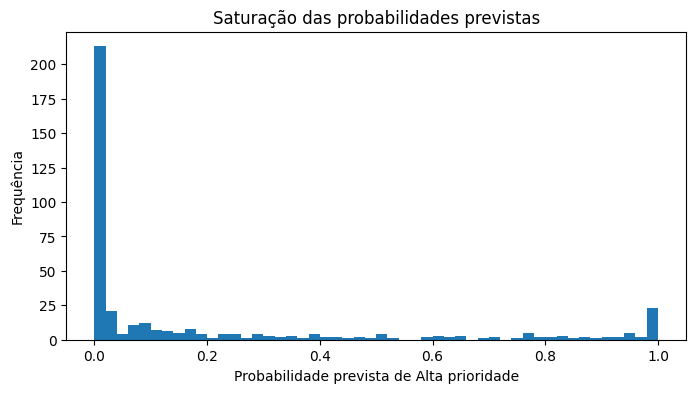

In [30]:
# As probabilidades saturam perto de 0 e de 1 porque as features quase determinam
# o alvo. Isso significa que a ORDEM no topo do ranking não é informativa:
# distinguir 0,999998 de 0,999990 não separa municípios de forma significativa.
print("Probabilidades de Alta — extremos:")
print(ranking['prob_alta'].describe())
print("\nObservações com prob_alta > 0,99:", (ranking['prob_alta'] > 0.99).sum())
print("Observações com prob_alta < 0,01:", (ranking['prob_alta'] < 0.01).sum())

plt.figure(figsize=(8, 4))
plt.hist(ranking['prob_alta'], bins=50)
plt.xlabel('Probabilidade prevista de Alta prioridade')
plt.ylabel('Frequência')
plt.title('Saturação das probabilidades previstas')
plt.show()


## 10. Interpretabilidade

Se o modelo final for linear, os **coeficientes já são a explicação exata** — o SHAP
apenas a redistribui por observação. Por isso os coeficientes vêm primeiro, e o SHAP
entra para as explicações locais.


In [31]:
modelo_interno = (
    modelo_final.named_steps['model']
    if isinstance(modelo_final, Pipeline) else modelo_final
)

if hasattr(modelo_interno, 'coef_'):
    coefs = pd.DataFrame(
        modelo_interno.coef_,
        columns=features_lag,
        index=['Baixa', 'Média', 'Alta']
    ).T
    print("Coeficientes (features padronizadas — comparáveis entre si):")
    display(coefs.round(3))
else:
    print("Modelo não linear: ver importâncias / SHAP abaixo.")


Coeficientes (features padronizadas — comparáveis entre si):


,Baixa,Média,Alta
lag_Homicídio Doloso por 100 mil habitantes,-1.737,0.136,1.600
lag_Furto por 100 mil habitantes,-1.974,0.111,1.864
lag_Roubo por 100 mil habitantes,-1.966,0.058,1.907
lag_Furto e Roubo de Veículo por 100 mil habitantes,-2.449,0.198,2.251


In [32]:
def predict_proba_shap(X):
    return modelo_final.predict_proba(pd.DataFrame(X, columns=features_lag))

# Masker explícito: evita a subamostragem silenciosa para 100 observações.
masker = shap.maskers.Independent(X_treino, max_samples=200)

explainer = shap.Explainer(predict_proba_shap, masker, feature_names=features_lag)
shap_values = explainer(X_teste)

print("Shape dos valores SHAP:", shap_values.values.shape)


Shape dos valores SHAP: (395, 4, 3)


Município: Diadema — Ano: 2017
Probabilidade de Alta: 1.0000


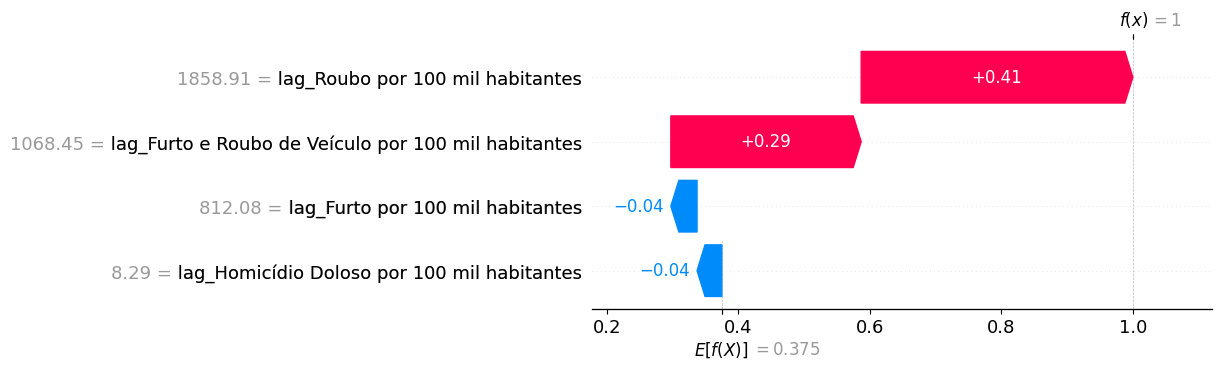

In [33]:
# Explicação local: por que este município-ano recebeu esta previsão?
idx_cidade = ranking.index[0]
posicao = X_teste.index.get_loc(idx_cidade)

print(f"Município: {teste_resultado.loc[idx_cidade, 'Cidade']} — "
      f"Ano: {teste_resultado.loc[idx_cidade, 'Ano']}")
print(f"Probabilidade de Alta: {teste_resultado.loc[idx_cidade, 'prob_alta']:.4f}")

shap.waterfall_plot(shap_values[posicao, :, 2])


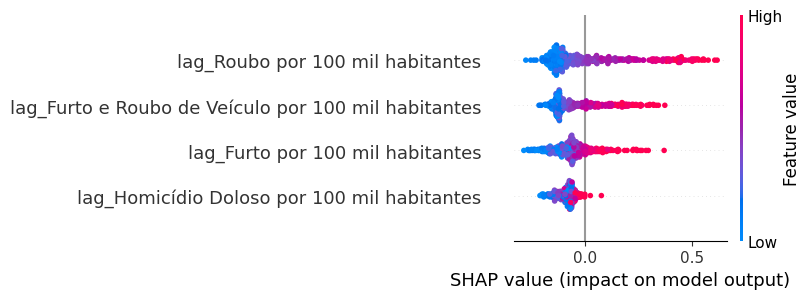

In [34]:
# Explicação global: quais variáveis mais pesam, e em que direção
shap.summary_plot(shap_values[:, :, 2], X_teste, feature_names=features_lag)


## 11. Limitações

**Circularidade do alvo (limitação central).** O alvo é função determinística dos
mesmos indicadores usados como features, defasados em um ano. O desempenho reflete
sobretudo a persistência temporal da criminalidade municipal — e, de fato, o baseline
de persistência supera todos os oito modelos no teste temporal (seção 8).

**Sensibilidade do índice aos pesos.** A especificação alternativa com peso 2 no
homicídio concorda com a de pesos iguais em 87,8% das observações, mas o índice
derivado de PCA concorda em apenas **61,7%**, e o primeiro componente explica somente
48,1% da variância. A classificação em tercis, portanto, **não é robusta** à escolha
de ponderação: a matriz de correlação mostra por quê — furto tem correlação negativa
com homicídio (−0,17) e praticamente nula com crime de veículo (−0,01), enquanto roubo
e crime de veículo se correlacionam fortemente (0,73). Não existe um único "fator
criminalidade" nos dados.

**Escopo.** 79 municípios de maior porte do estado de São Paulo, não os 645. Não
generaliza para municípios pequenos nem para outros estados.

**Denominador das taxas.** Taxas por 100 mil habitantes residentes superestimam polos
regionais e municípios litorâneos (seção 2.2). Três colunas apresentaram zeros
logicamente impossíveis, tratados como ausentes (seção 2.1).

**Probabilidades saturadas.** 21 das 395 observações de teste recebem probabilidade de
"Alta" acima de 0,99 e 200 abaixo de 0,01. A ordenação no topo do ranking não é
informativa: distinguir 0,999999 de 0,999995 não separa municípios de forma
significativa.

**Crime registrado ≠ crime ocorrido.** O modelo aprende sobre notificação policial, que
depende de cobertura de policiamento e de propensão da população a registrar
ocorrência. Modelar alocação policial a partir de crime registrado tem risco conhecido
de **retroalimentação**: mais policiamento gera mais registro, que gera mais previsão
de prioridade (Lum & Isaac, 2016, *To predict and serve?*).

**Ausência de covariáveis.** Não há variáveis socioeconômicas, demográficas, urbanas ou
de efetivo policial. As classes são relativas ao índice construído, não a um critério
externo de gravidade.

**Sem causalidade.** O modelo identifica associação estatística e não sustenta
inferência causal nem recomendação operacional.
